In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import shutil

merged_dir = "/content/merged_data"

classes = ["glioma", "meningioma", "pituitary", "notumor"]

for c in classes:
    os.makedirs(os.path.join(merged_dir, c), exist_ok=True)

print("Merged folder created")


Merged folder created


In [ ]:
old_data = "/content/drive/MyDrive/data"

for c in classes:
    src = os.path.join(old_data, c)
    dst = os.path.join(merged_dir, c)

    for file in os.listdir(src):
        shutil.copy(os.path.join(src, file), dst)

print("Old dataset merged")


Old dataset merged


In [ ]:
data2_train = "/content/drive/MyDrive/data2/Training"
data2_test  = "/content/drive/MyDrive/data2/Testing"

mapping = {
    "glioma_tumor": "glioma",
    "meningioma_tumor": "meningioma",
    "pituitary_tumor": "pituitary",
    "no_tumor": "notumor"
}

for dataset in [data2_train, data2_test]:
    for src_class, dst_class in mapping.items():
        src = os.path.join(dataset, src_class)
        dst = os.path.join(merged_dir, dst_class)

        for file in os.listdir(src):
            shutil.copy(os.path.join(src, file), dst)

print("New dataset merged")


New dataset merged


In [ ]:
import os, time, copy, numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms, models
from PIL import Image


DATA_DIR = "/content/merged_data"
OUTPUT_DIR = "/content/drive/MyDrive/data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 20
LR = 1e-5
WEIGHT_DECAY = 1e-4
SEED = 42
NUM_WORKERS = 2
PATIENCE = 8  # early stopping

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(SEED)
np.random.seed(SEED)

train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.12, contrast=0.12),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.1)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


full_dataset = datasets.ImageFolder(DATA_DIR)
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Total images:", len(full_dataset))

targets = [s[1] for s in full_dataset.samples]

train_idx, temp_idx = train_test_split(
    np.arange(len(full_dataset)),
    test_size=0.3,
    stratify=targets,
    random_state=SEED
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=[targets[i] for i in temp_idx],
    random_state=SEED
)

class CustomImageDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_samples = [full_dataset.samples[i] for i in train_idx]
val_samples   = [full_dataset.samples[i] for i in val_idx]
test_samples  = [full_dataset.samples[i] for i in test_idx]

train_dataset = CustomImageDataset(train_samples, transform=train_tfms)
val_dataset   = CustomImageDataset(val_samples, transform=val_tfms)
test_dataset  = CustomImageDataset(test_samples, transform=val_tfms)



train_labels = [targets[i] for i in train_idx]
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)

print("Train class counts:", dict(zip(class_names, class_counts)))

class_weights = 1.0 / (class_counts + 1e-6)
sample_weights = torch.DoubleTensor([class_weights[t] for t in train_labels])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



model = models.resnet50(pretrained=True)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace FC
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights).float().to(device))


optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

print("\n===== STAGE 1: Training FC layer =====")

for epoch in range(3):
    model.train()
    correct, total, loss_total = 0,0,0

    for imgs, labels in tqdm(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        loss_total += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | Acc: {correct/total:.4f}")


for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

best_auc = 0
trigger = 0

print("\n===== STAGE 2: Fine-tuning =====")

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    # TRAIN
    model.train()
    correct,total = 0,0

    for imgs, labels in tqdm(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct/total

    # VALIDATION
    model.eval()
    correct,total = 0,0
    all_probs, all_targets = [],[]

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)

            probs = torch.softmax(outputs.cpu(), dim=1).numpy()
            preds = np.argmax(probs, axis=1)

            all_probs.append(probs)
            all_targets.append(labels.cpu().numpy())

            correct += (preds == labels.cpu().numpy()).sum()
            total += imgs.size(0)

    val_acc = correct/total
    all_probs = np.vstack(all_probs)
    all_targets = np.concatenate(all_targets)

    try:
        val_auc = roc_auc_score(all_targets, all_probs, multi_class='ovr')
    except:
        val_auc = 0

    scheduler.step()

    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

    # SAVE BEST
    if val_auc > best_auc:
        best_auc = val_auc
        trigger = 0
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, OUTPUT_DIR + "/best_brain_tumor_model.pth")
        print("Saved best model")
    else:
        trigger += 1

    # EARLY STOPPING
    if trigger >= PATIENCE:
        print("Early stopping triggered")
        break


model.load_state_dict(best_state)
model.eval()

all_preds, all_labels = [],[]

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs.cpu(), dim=1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print("\nFINAL TEST ACCURACY:", np.mean(np.array(all_preds)==np.array(all_labels)))
print("\nCONFUSION MATRIX:")
print(confusion_matrix(all_labels, all_preds))

print("\nCLASSIFICATION REPORT:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Total images: 4472
Train class counts: {'glioma': np.int64(858), 'meningioma': np.int64(870), 'notumor': np.int64(561), 'pituitary': np.int64(841)}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



===== STAGE 1: Training FC layer =====


100%|██████████| 98/98 [00:18<00:00,  5.18it/s]


Epoch 1 | Acc: 0.6422


...

Train Acc: 0.9936 | Val Acc: 0.9613 | Val AUC: 0.9956

Epoch 19/20


100%|██████████| 21/21 [00:03<00:00,  6.26it/s]


Train Acc: 0.9936 | Val Acc: 0.9568 | Val AUC: 0.9956

Epoch 20/20


100%|██████████| 21/21 [00:04<00:00,  5.07it/s]


Train Acc: 0.9939 | Val Acc: 0.9598 | Val AUC: 0.9958
Saved best model

FINAL TEST ACCURACY: 0.9448584202682563

CONFUSION MATRIX:
[[168  10   5   1]
 [  4 166   2  15]
 [  0   0 120   0]
 [  0   0   0 180]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma       0.98      0.91      0.94       184
  meningioma       0.94      0.89      0.91       187
     notumor       0.94      1.00      0.97       120
   pituitary       0.92      1.00      0.96       180

    accuracy                           0.94       671
   macro avg       0.95      0.95      0.95       671
weighted avg       0.95      0.94      0.94       671



In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/data/final_brain_tumor_model.pth")


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt


MODEL_PATH = "/content/drive/MyDrive/data/final_brain_tumor_model.pth"

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully")


transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred_class = torch.max(probs, 1)

    predicted_label = class_names[pred_class.item()]
    confidence_score = confidence.item()

    # show image
    plt.imshow(image)
    plt.title(f"Prediction: {predicted_label} | Confidence: {confidence_score:.2f}")
    plt.axis("off")
    plt.show()

    print("Predicted Tumor:", predicted_label)
    print("Confidence:", confidence_score)

    return predicted_label, confidence_score


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully


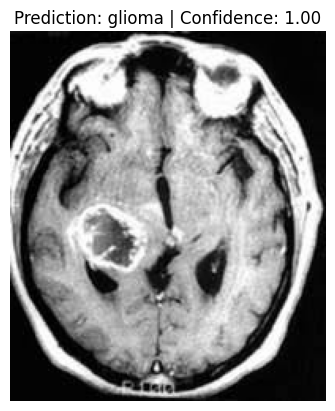

Predicted Tumor: glioma
Confidence: 0.9995915293693542


('glioma', 0.9995915293693542)

In [ ]:
predict_image("glioma2.jpg")


In [ ]:
!pip install grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import numpy as np

def generate_gradcam(image_path):

    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize ORIGINAL image to match model input
    image_resized = cv2.resize(image, (224,224))

    rgb_img = image_resized.astype(np.float32) / 255.0

    input_tensor = transform(Image.fromarray(image_resized)).unsqueeze(0).to(device)

    # last conv layer of ResNet
    target_layers = [model.layer4[-1]]

    cam = GradCAM(model=model, target_layers=target_layers)

    # Forward pass
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_class = torch.argmax(probs).item()

    # Generate heatmap
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    # Overlay
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original MRI")
    plt.imshow(image_resized)
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(grayscale_cam, cmap='jet')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title(f"Overlay | {class_names[pred_class]}")
    plt.imshow(visualization)
    plt.axis('off')

    plt.show()

    print("Predicted Tumor:", class_names[pred_class])



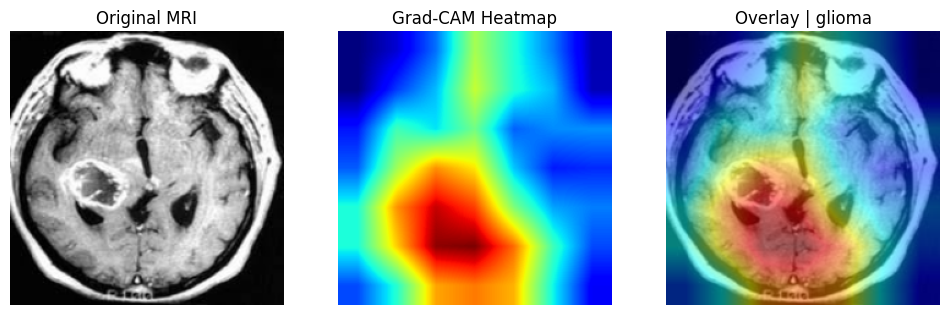

Predicted Tumor: glioma


In [ ]:
generate_gradcam("glioma2.jpg")


In [ ]:
!pip install streamlit
!pip install pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 43.4 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1


In [ ]:
%%writefile app.py


Writing app.py


In [ ]:
import streamlit as st
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

############################################
# CONFIG
############################################

MODEL_PATH = "/content/drive/MyDrive/data/final_brain_tumor_model.pth"

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

############################################
# LOAD MODEL
############################################

model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

############################################
# TRANSFORM
############################################

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

############################################
# STREAMLIT UI
############################################

st.title("🧠 Brain Tumor Classification using ResNet50 + GradCAM")
st.write("Upload an MRI image to predict tumor type")

uploaded_file = st.file_uploader("Upload MRI Image", type=["jpg","png","jpeg"])

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded MRI", use_column_width=True)

    ########################################
    # PREDICTION
    ########################################

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, pred_class = torch.max(probs, 1)

    predicted_label = class_names[pred_class.item()]
    confidence_score = confidence.item()

    st.subheader(f"Prediction: {predicted_label}")
    st.write(f"Confidence: {confidence_score:.2f}")

    ########################################
    # GRAD-CAM
    ########################################

    image_np = np.array(image)
    image_resized = cv2.resize(image_np, (224,224))
    rgb_img = image_resized.astype(np.float32) / 255.0

    target_layers = [model.layer4[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)

    grayscale_cam = cam(input_tensor=input_tensor)[0]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    st.subheader("Grad-CAM Explanation")
    st.image(visualization, use_column_width=True)


2026-02-17 20:49:26.674 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 20:49:26.803 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-02-17 20:49:26.803 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 20:49:26.807 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 20:49:26.809 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 20:49:26.813 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 20:49:26.814 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 20:49:26.816 Thread 'MainThread': mi

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501


⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://beige-moles-stay.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.163.41:8501

  Stopping...
^C
